In [113]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import psutil
import gc

In [114]:
def print_memory():
    print(f"RAM: {psutil.virtual_memory().percent}% used "
          f"({psutil.virtual_memory().available / 1e9:.1f} GB free)")

print("Starting MovieLens Matrix Completion")
print_memory()

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cpu')
print(f"Using device: {device}")

Starting MovieLens Matrix Completion
RAM: 16.1% used (11.4 GB free)
Using device: cpu


In [115]:
print("DATA LOADING & PREPROCESSING")
print("Loading data...")
df = pd.read_csv('u.data', sep='\t',
                 names=['user_id','item_id','rating','ts'], usecols=[0,1,2])

print(f"\nOriginal dataset statistics:")
print(f"  - Total ratings: {len(df)}")
print(f"  - Unique users: {df['user_id'].nunique()}")
print(f"  - Unique items: {df['item_id'].nunique()}")
print(f"  - Rating range: [{df['rating'].min()}, {df['rating'].max()}]")
print(f"  - Mean rating: {df['rating'].mean():.2f}")
print(f"  - Median rating: {df['rating'].median():.2f}")

DATA LOADING & PREPROCESSING
Loading data...

Original dataset statistics:
  - Total ratings: 100000
  - Unique users: 943
  - Unique items: 1682
  - Rating range: [1, 5]
  - Mean rating: 3.53
  - Median rating: 4.00


In [116]:
# Adjust indices to 0-based
df['user_id'] -= 1
df['item_id'] -= 1

# Downsample
df = df[df['user_id'] < 200]
df = df[df['item_id'] < 300]

m, n = 200, 300
print(f"\nDownsampled dataset:")
print(f"  - Users: {m}")
print(f"  - Items: {n}")
print(f"  - Observed ratings: {len(df)}")
print(f"  - Missing: {(1 - len(df)/(m*n))*100:.2f}%")
print_memory()


Downsampled dataset:
  - Users: 200
  - Items: 300
  - Observed ratings: 9409
  - Missing: 84.32%
RAM: 16.1% used (11.4 GB free)


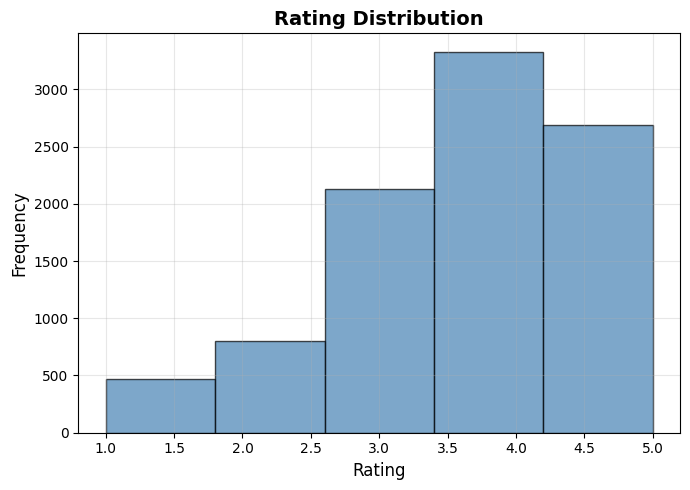

In [117]:
os.makedirs("results", exist_ok=True)

# Rating histogram
plt.figure(figsize=(7, 5))
plt.hist(df['rating'], bins=5, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Rating Distribution', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results/01_rating_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
plt.close()


In [118]:
print("Rating distribution:")
for rating in sorted(df['rating'].unique()):
    count = (df['rating'] == rating).sum()
    pct = count / len(df) * 100
    print(f"  Rating {int(rating)}: {count:5d} ({pct:5.2f}%)")


Rating distribution:
  Rating 1:   466 ( 4.95%)
  Rating 2:   801 ( 8.51%)
  Rating 3:  2132 (22.66%)
  Rating 4:  3323 (35.32%)
  Rating 5:  2687 (28.56%)


In [119]:
print("Creating 200×300 rating matrix...")
R = torch.zeros(m, n)

ratings = df[['user_id','item_id','rating']].values
obs_idx = torch.from_numpy(ratings[:,:2].astype(np.int64))
obs_r   = torch.from_numpy(ratings[:,2].astype(np.float32))

R[obs_idx[:,0], obs_idx[:,1]] = obs_r
n_observed = R.nonzero().size(0)
print(f"Matrix created: {R.shape}, {n_observed} observed ratings")

# User and item activity
user_activity = (R > 0).sum(dim=1).numpy()
item_activity = (R > 0).sum(dim=0).numpy()

print(f"  - Mean ratings per user: {user_activity.mean():.2f}")
print(f"  - Mean ratings per item: {item_activity.mean():.2f}")


Creating 200×300 rating matrix...
Matrix created: torch.Size([200, 300]), 9409 observed ratings
  - Mean ratings per user: 47.05
  - Mean ratings per item: 31.36


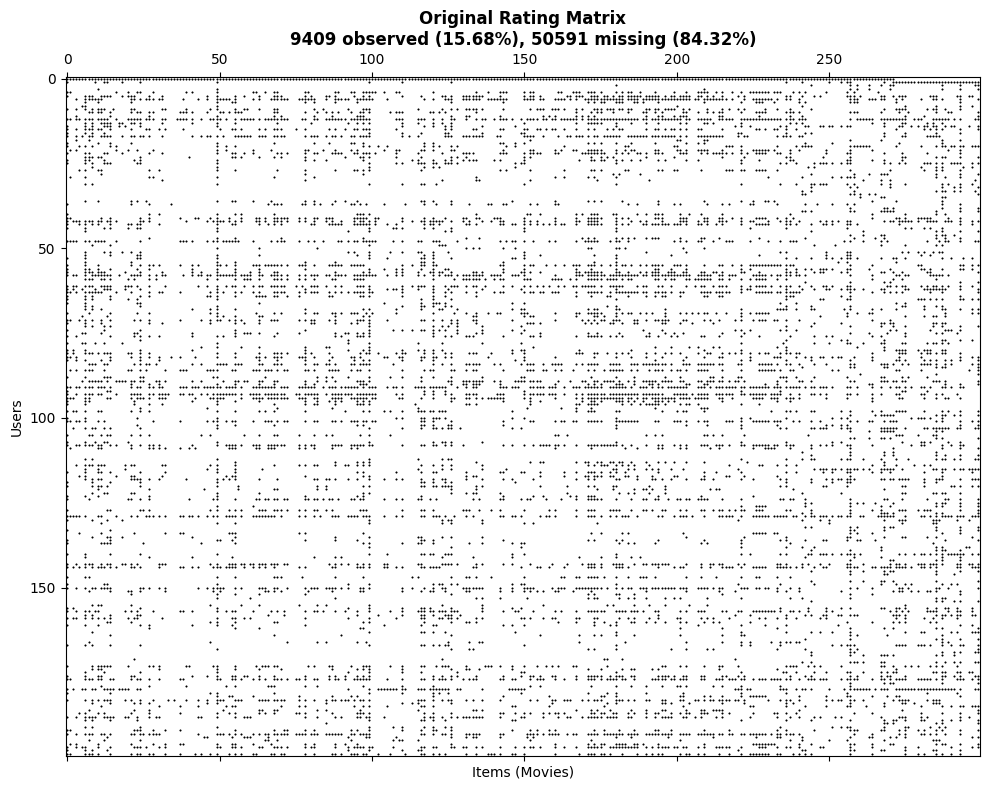

In [120]:
plt.figure(figsize=(10, 8))
plt.spy(R, markersize=0.5, color='black', aspect='auto')
plt.title(f"Original Rating Matrix\n{n_observed} observed ({(n_observed/(m*n)*100):.2f}%), {m*n - n_observed} missing ({((m*n - n_observed)/(m*n)*100):.2f}%)",
          fontsize=12, fontweight='bold')
plt.xlabel("Items (Movies)", fontsize=10)
plt.ylabel("Users", fontsize=10)
plt.tight_layout()
plt.savefig("results/02_sparse_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
plt.close()

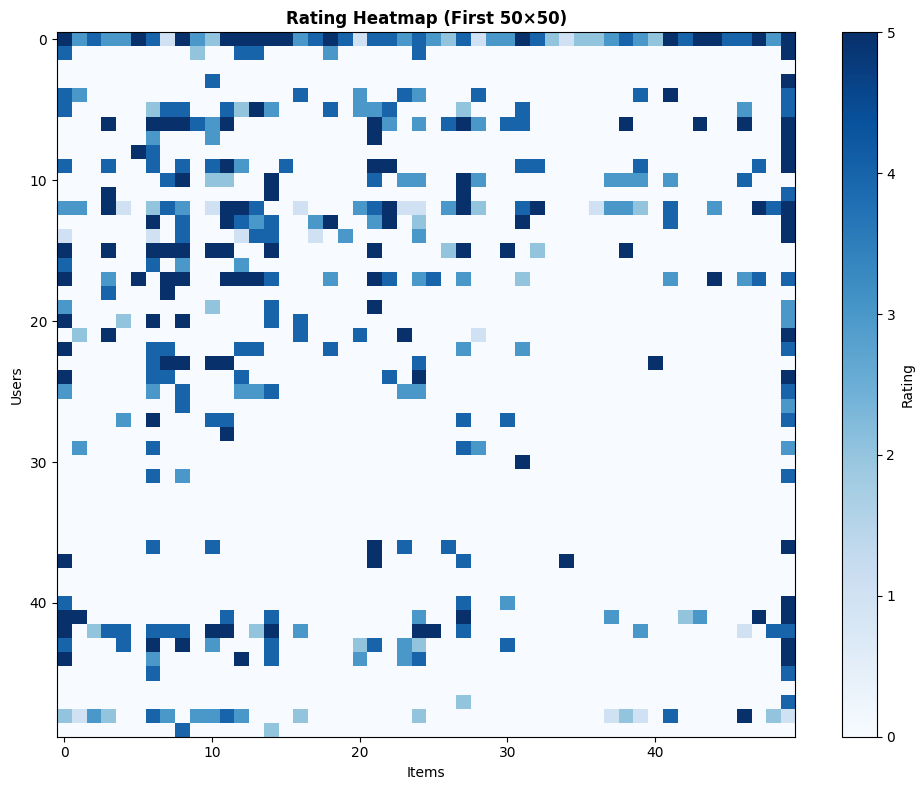

In [121]:
plt.figure(figsize=(10, 8))
R_subset = R[:50, :50].numpy()
plt.imshow(R_subset, cmap='Blues', aspect='auto', interpolation='nearest')
plt.title('Rating Heatmap (First 50×50)', fontsize=12, fontweight='bold')
plt.xlabel('Items', fontsize=10)
plt.ylabel('Users', fontsize=10)
plt.colorbar(label='Rating')
plt.tight_layout()
plt.savefig("results/02_rating_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
plt.close()


In [122]:
ratio_obs = 0.5
mask = torch.zeros(m, n, dtype=torch.bool)
mask[obs_idx[:,0], obs_idx[:,1]] = True
obs_mask = (torch.rand(m, n) < ratio_obs) & mask

idx = torch.nonzero(obs_mask, as_tuple=False)
perm = torch.randperm(len(idx))
split = len(idx) // 10  # 10% test
train_idx, test_idx = idx[perm[split:]], idx[perm[:split]]

train_u, train_i = train_idx[:,0], train_idx[:,1]
test_u , test_i  = test_idx[:,0] , test_idx[:,1]

flat_all   = obs_idx[:,0]*n + obs_idx[:,1]
flat_train = train_u*n + train_i
flat_test  = test_u*n + test_i
train_r = obs_r[torch.isin(flat_all, flat_train)]
test_r  = obs_r[torch.isin(flat_all, flat_test)]

print(f"Train set: {len(train_r)} ratings")
print(f"Test set: {len(test_r)} ratings")
print(f"Split ratio: {len(test_r)/(len(train_r)+len(test_r))*100:.2f}% test")

Train set: 4255 ratings
Test set: 472 ratings
Split ratio: 9.99% test


In [123]:
rank = 10
class PMF(nn.Module):
    def __init__(self, m, n, k):
        super().__init__()
        self.U = nn.Parameter(torch.randn(m, k) * 0.1)
        self.V = nn.Parameter(torch.randn(n, k) * 0.1)

    def forward(self, u, i):
        return (self.U[u] * self.V[i]).sum(1)

pmf = PMF(m, n, rank)
opt = torch.optim.Adam(pmf.parameters(), lr=1e-2)

train_loss, test_loss = [], []
print("Training PMF (rank=10, 100 epochs)...")
for epoch in range(100):
    pmf.train()
    opt.zero_grad()
    p = pmf(train_u, train_i)
    loss = ((p - train_r) ** 2).mean()
    loss.backward()
    opt.step()
    train_loss.append(loss.item())

    pmf.eval()
    with torch.no_grad():
        tp = pmf(test_u, test_i)
        test_loss.append(((tp - test_r) ** 2).mean().item())

    if (epoch + 1) % 20 == 0:
        print(f"  Epoch {epoch+1:3d}: Train RMSE = {np.sqrt(train_loss[-1]):.4f}, Test RMSE = {np.sqrt(test_loss[-1]):.4f}")

pmf_rmse = np.sqrt(test_loss[-1])
print(f"\nFinal PMF Test RMSE: {pmf_rmse:.4f}")


Training PMF (rank=10, 100 epochs)...
  Epoch  20: Train RMSE = 3.6987, Test RMSE = 3.7870
  Epoch  40: Train RMSE = 2.7411, Test RMSE = 2.8855
  Epoch  60: Train RMSE = 1.2416, Test RMSE = 1.3896
  Epoch  80: Train RMSE = 1.0246, Test RMSE = 1.2295
  Epoch 100: Train RMSE = 0.9607, Test RMSE = 1.2724

Final PMF Test RMSE: 1.2724


In [124]:
pmf.eval()
with torch.no_grad():
    # Predict all entries
    all_users = torch.arange(m).unsqueeze(1).expand(m, n).reshape(-1)
    all_items = torch.arange(n).unsqueeze(0).expand(m, n).reshape(-1)
    R_completed_pmf = pmf(all_users, all_items).reshape(m, n).clamp(1, 5)

print(f"Completed matrix shape: {R_completed_pmf.shape}")
print(f"Completed matrix stats:")
print(f"  - Min: {R_completed_pmf.min():.2f}")
print(f"  - Max: {R_completed_pmf.max():.2f}")
print(f"  - Mean: {R_completed_pmf.mean():.2f}")

Completed matrix shape: torch.Size([200, 300])
Completed matrix stats:
  - Min: 1.00
  - Max: 5.00
  - Mean: 3.22


In [125]:
tokens = torch.stack([train_u.float(), train_i.float(), train_r], dim=1)
train_q = torch.stack([train_u.float(), train_i.float()], dim=1)

# Selecting missing entries for imputation
miss = torch.nonzero(~obs_mask, as_tuple=False)
query = torch.stack([miss[:,0].float(), miss[:,1].float()], dim=1)

class TinyPerceiver(nn.Module):
    def __init__(self, embed_dim=32, heads=4):
        super().__init__()
        self.tok_proj = nn.Linear(3, embed_dim)
        self.qry_proj = nn.Linear(2, embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, heads, batch_first=True)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, 1)
        )
        self.norm_tok = nn.LayerNorm(embed_dim)
        self.norm_qry = nn.LayerNorm(embed_dim)
        self.norm_out = nn.LayerNorm(embed_dim)
        self.rating_bias = nn.Parameter(torch.tensor(0.0))

    def forward(self, tok, qry):
        x = self.norm_tok(self.tok_proj(tok))
        q = self.norm_qry(self.qry_proj(qry))
        o, _ = self.attn(q, x, x)
        o = self.norm_out(o + q)
        out = self.mlp(o).squeeze(-1)
        return out + self.rating_bias

perc = TinyPerceiver(embed_dim=32, heads=4)
opt_p = torch.optim.Adam(perc.parameters(), lr=3e-3)

print("Training TinyPerceiver (120 epochs)...")
perc_losses = []
for epoch in range(120):
    perc.train()
    opt_p.zero_grad()
    pred = perc(tokens, train_q)
    loss = ((pred - train_r) ** 2).mean()
    loss.backward()
    opt_p.step()
    perc_losses.append(loss.item())

    if epoch % 20 == 0:
        print(f"  Epoch {epoch:3d}: Loss = {loss.item():.4f}, RMSE = {np.sqrt(loss.item()):.4f}")
    if epoch % 10 == 0:
        gc.collect()

with torch.no_grad():
    logits = perc(tokens, query).clamp(0, 5)

print("10 imputed ratings:", logits.tolist())


perc.eval()
with torch.no_grad():
    test_query = torch.stack([test_u.float(), test_i.float()], dim=1)
    pred_test = perc(tokens, test_query)
    perc_test_rmse = torch.sqrt(F.mse_loss(pred_test, test_r)).item()

print(f"\nFinal Perceiver Train RMSE: {np.sqrt(perc_losses[-1]):.4f}")
print(f"Final Perceiver Test RMSE: {perc_test_rmse:.4f}")


Training TinyPerceiver (120 epochs)...
  Epoch   0: Loss = 15.2282, RMSE = 3.9023
  Epoch  20: Loss = 1.7662, RMSE = 1.3290
  Epoch  40: Loss = 1.3007, RMSE = 1.1405
  Epoch  60: Loss = 1.2496, RMSE = 1.1179
  Epoch  80: Loss = 1.2456, RMSE = 1.1161
  Epoch 100: Loss = 1.2450, RMSE = 1.1158
10 imputed ratings: [2.8980889320373535, 3.40097975730896, 3.6109378337860107, 3.647998094558716, 3.6610400676727295, 3.664679527282715, 3.6693968772888184, 3.6709978580474854, 3.672285318374634, 3.673340082168579, 3.6742186546325684, 3.6755969524383545, 3.6761465072631836, 3.677046060562134, 3.678321123123169, 3.679348945617676, 3.679654359817505, 3.679917812347412, 3.6800365447998047, 3.680251359939575, 3.680349111557007, 3.680440664291382, 3.680527448654175, 3.6806867122650146, 3.6808292865753174, 3.6808953285217285, 3.6809580326080322, 3.681074619293213, 3.68112850189209, 3.6811811923980713, 3.6814088821411133, 3.6814494132995605, 3.681488513946533, 3.681525468826294, 3.681595802307129, 3.681661

In [126]:
print("\nCompleting matrix with Perceiver...")
perc.eval()
with torch.no_grad():
    R_completed_perc = R.clone()

    batch_size = 1000
    for i in range(0, len(query), batch_size):
        batch_query = query[i:i+batch_size]
        imputed = perc(tokens, batch_query).clamp(1, 5)
        for j, rating in enumerate(imputed):
            u, it = int(batch_query[j, 0]), int(batch_query[j, 1])
            R_completed_perc[u, it] = rating

print(f"Perceiver completed matrix stats:")
print(f"  - Min: {R_completed_perc.min():.2f}")
print(f"  - Max: {R_completed_perc.max():.2f}")
print(f"  - Mean: {R_completed_perc.mean():.2f}")


Completing matrix with Perceiver...
Perceiver completed matrix stats:
  - Min: 1.00
  - Max: 5.00
  - Mean: 3.74


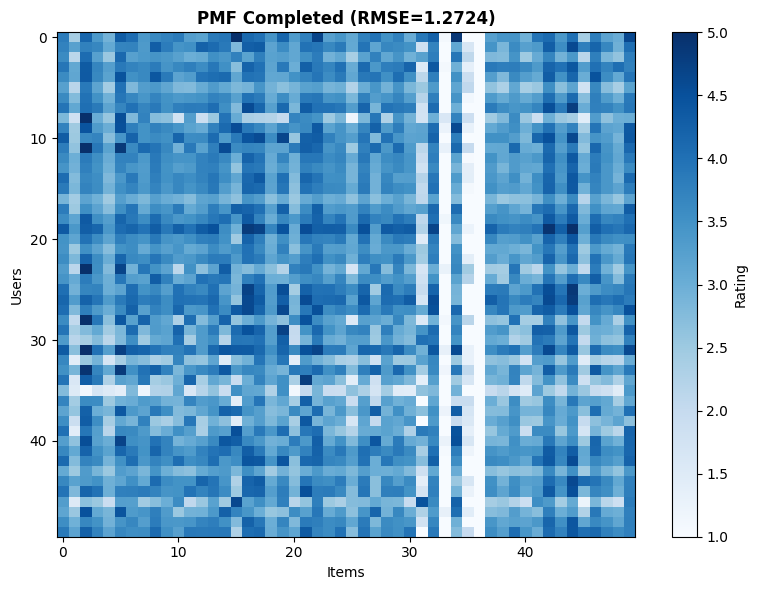

In [127]:
plt.figure(figsize=(8,6))
R_pmf_np = R_completed_pmf.numpy()
plt.imshow(R_pmf_np[:50, :50], cmap='Blues', aspect='auto', vmin=1, vmax=5)
plt.title(f'PMF Completed (RMSE={pmf_rmse:.4f})', fontsize=12, fontweight='bold')
plt.xlabel('Items', fontsize=10)
plt.ylabel('Users', fontsize=10)
plt.colorbar(label='Rating')
plt.tight_layout()
plt.savefig("results/04_pmf_completed.png", dpi=150, bbox_inches='tight')
plt.show()
plt.close()

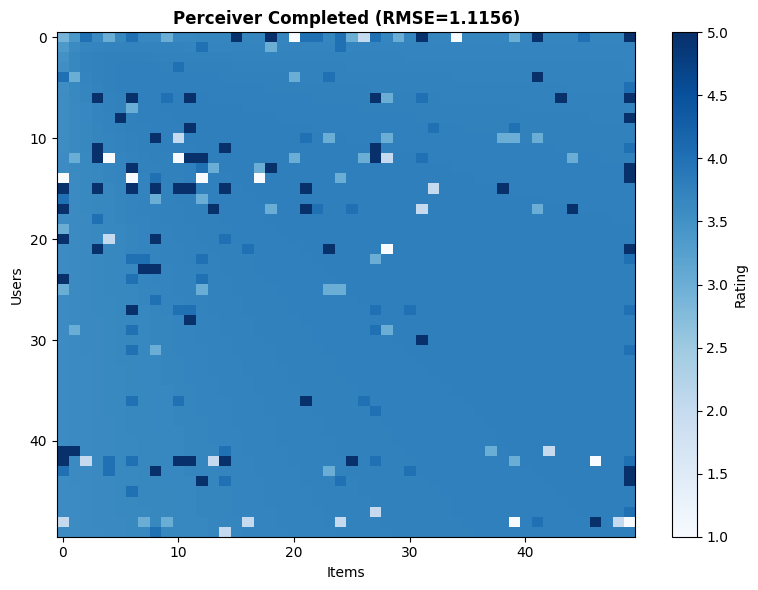

In [128]:
plt.figure(figsize=(8, 6))
R_perc_np = R_completed_perc.numpy()
plt.imshow(R_perc_np[:50, :50], cmap='Blues', aspect='auto', vmin=1, vmax=5)
plt.title(f'Perceiver Completed (RMSE={np.sqrt(perc_losses[-1]):.4f})', fontsize=12, fontweight='bold')
plt.xlabel('Items', fontsize=10)
plt.ylabel('Users', fontsize=10)
plt.colorbar(label='Rating')
plt.tight_layout()
plt.savefig("results/04_perceiver_completed.png", dpi=150, bbox_inches='tight')
plt.show()
plt.close()

In [129]:
tokens = torch.stack([train_u.float(), train_i.float(), train_r], dim=1)

class PerceiverGraphIO(nn.Module):
    def __init__(self, latent_dim=64, heads=4, layers=2):
        super().__init__()
        self.node_emb = nn.Embedding(m + n, latent_dim)  # user + item nodes
        self.token_proj = nn.Linear(3, latent_dim)
        self.query_proj = nn.Linear(2, latent_dim)

        self.latent = nn.Parameter(torch.randn(1, 32, latent_dim))

        self.cross_attn = nn.MultiheadAttention(latent_dim, heads, batch_first=True)
        self.self_attn = nn.ModuleList([
            nn.MultiheadAttention(latent_dim, heads, batch_first=True) for _ in range(layers)
        ])
        self.mlp = nn.Sequential(
            nn.Linear(latent_dim, latent_dim), nn.GELU(),
            nn.Linear(latent_dim, 1)
        )

    def forward(self, tokens, query_ui):
        batch = 1
        S = tokens.size(0)
        x = self.token_proj(tokens).unsqueeze(0)
        u_ids = tokens[:,0].long()
        i_ids = tokens[:,1].long() + m
        node_ids = torch.cat([u_ids, i_ids])
        node_embs = self.node_emb(node_ids).unsqueeze(0)

        L = self.latent.expand(batch, -1, -1)
        L, _ = self.cross_attn(L, torch.cat([x, node_embs], dim=1), torch.cat([x, node_embs], dim=1))

        for layer in self.self_attn:
            L, _ = layer(L, L, L)
        q_u = query_ui[:, 0].long()
        q_i = query_ui[:, 1].long() + m
        user_embs = self.node_emb(q_u)
        item_embs = self.node_emb(q_i)
        q = (user_embs + item_embs).unsqueeze(0)

        out, _ = self.cross_attn(q, L, L)
        return self.mlp(out).squeeze(-1).squeeze(0)

In [130]:
graph_perc = PerceiverGraphIO(latent_dim=64, heads=4, layers=2).to(device)
opt_g = torch.optim.Adam(graph_perc.parameters(), lr=1e-3)

print("Training Perceiver-Graph-IO (120 epochs)...")
graph_losses = []
for epoch in range(120):
    graph_perc.train()
    opt_g.zero_grad()
    pred = graph_perc(tokens, tokens[:, :2])
    loss = F.mse_loss(pred, train_r)
    loss.backward()
    opt_g.step()
    graph_losses.append(loss.item())

    if epoch % 20 == 0:
        print(f"  Epoch {epoch:3d}: Loss = {loss.item():.4f}, RMSE = {np.sqrt(loss.item()):.4f}")
    if epoch % 10 == 0:
        gc.collect()


with torch.no_grad():
    logits = graph_perc(tokens, query).clamp(0, 5)
print("10 imputed ratings:", logits.tolist())


Training Perceiver-Graph-IO (120 epochs)...
  Epoch   0: Loss = 19.8294, RMSE = 4.4530
  Epoch  20: Loss = 1.2876, RMSE = 1.1347
  Epoch  40: Loss = 1.2434, RMSE = 1.1151
  Epoch  60: Loss = 1.2464, RMSE = 1.1164
  Epoch  80: Loss = 1.2411, RMSE = 1.1140
  Epoch 100: Loss = 1.2411, RMSE = 1.1140
10 imputed ratings: [3.734532117843628, 3.734532117843628, 3.734532356262207, 3.734532356262207, 3.734532117843628, 3.7345316410064697, 3.734531879425049, 3.734532117843628, 3.734532594680786, 3.734532117843628, 3.7345316410064697, 3.734532117843628, 3.734532117843628, 3.734532594680786, 3.734532356262207, 3.734531879425049, 3.734531879425049, 3.734532594680786, 3.7345316410064697, 3.734532356262207, 3.734532594680786, 3.734532356262207, 3.734532117843628, 3.7345311641693115, 3.7345311641693115, 3.7345316410064697, 3.734532117843628, 3.734532117843628, 3.7345314025878906, 3.734532356262207, 3.7345316410064697, 3.7345314025878906, 3.734532356262207, 3.734532117843628, 3.7345316410064697, 3.73453

In [131]:
graph_perc.eval()
with torch.no_grad():
    test_query = torch.stack([test_u, test_i], dim=1).float()
    pred_test = graph_perc(tokens, test_query)
    graph_test_rmse = torch.sqrt(F.mse_loss(pred_test, test_r)).item()

print(f"\nFinal GraphPerceiver RMSE: {np.sqrt(graph_losses[-1]):.4f}")
print(f"Final Graph-Perceiver Test RMSE: {graph_test_rmse:.4f}")


Final GraphPerceiver RMSE: 1.1140
Final Graph-Perceiver Test RMSE: 1.0741


In [132]:
truly_missing_mask = (R == 0)
truly_missing = torch.nonzero(truly_missing_mask, as_tuple=False)
print(f"Total truly missing entries: {len(truly_missing)}")

with torch.no_grad():
    R_completed_graph = R.clone()
    # Impute missing values in batches
    batch_size = 1000
    for i in range(0, len(truly_missing), batch_size):
        batch_miss = truly_missing[i:i+batch_size]
        batch_query = batch_miss.float()
        imputed = graph_perc(tokens, batch_query).clamp(1, 5)
        for j, rating in enumerate(imputed):
            u, it = int(batch_miss[j, 0]), int(batch_miss[j, 1])
            R_completed_graph[u, it] = rating

# Verify completion
remaining_zeros = (R_completed_graph == 0).sum().item()
print(f"Remaining zeros after completion: {remaining_zeros}")

print(f"Graph-Perceiver completed matrix stats:")
print(f"  - Min: {R_completed_graph.min():.2f}")
print(f"  - Max: {R_completed_graph.max():.2f}")
print(f"  - Mean: {R_completed_graph.mean():.2f}")
print(f"  - Std: {R_completed_graph.std():.2f}")

Total truly missing entries: 50591
Remaining zeros after completion: 0
Graph-Perceiver completed matrix stats:
  - Min: 1.00
  - Max: 5.00
  - Mean: 3.74
  - Std: 0.44


In [133]:
print(f"Total missing entries: {len(miss)}")
print(f"Entries to impute: {len(miss)}")
print(f"Remaining zeros: {(R_completed_graph == 0).sum()}")

Total missing entries: 55273
Entries to impute: 55273
Remaining zeros: 0


In [134]:
miss = torch.nonzero(~obs_mask, as_tuple=False)[:10]
query = miss.float()
with torch.no_grad():
    imputed = graph_perc(tokens, query).clamp(0, 5)
print("10 imputed (Graph-IO):", imputed.tolist())

10 imputed (Graph-IO): [3.734532117843628, 3.734532117843628, 3.734532356262207, 3.734532356262207, 3.734532117843628, 3.7345316410064697, 3.734531879425049, 3.734532117843628, 3.734532594680786, 3.734532117843628]


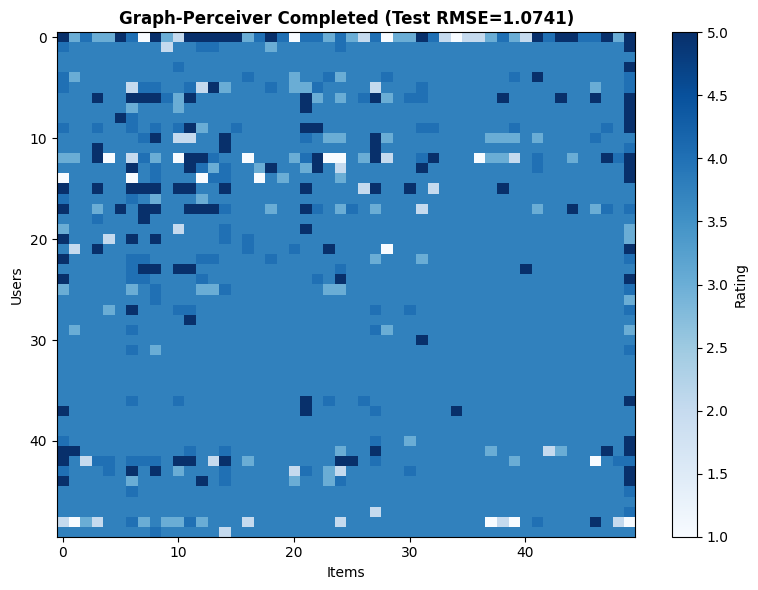

In [135]:
plt.figure(figsize=(8,6))
R_graph_np = R_completed_graph.numpy()
plt.imshow(R_graph_np[:50, :50], cmap='Blues', aspect='auto', vmin=1, vmax=5)
plt.title(f'Graph-Perceiver Completed (Test RMSE={graph_test_rmse:.4f})', fontsize=12, fontweight='bold')
plt.xlabel('Items', fontsize=10)
plt.ylabel('Users', fontsize=10)
plt.colorbar(label='Rating')
plt.tight_layout()
plt.savefig("results/04_graph_perceiver_completed.png", dpi=150, bbox_inches='tight')
plt.show()
plt.close()